In [ ]:
# ==============================================================================
# 13. SHAP Analysis (모델 해석)
# ==============================================================================
#
# 목적:
#   1. v2 모델 SHAP 분석
#   2. v1 vs v2 Feature Importance 비교
#   3. FE 피처 효과 검증
# ==============================================================================

import pandas as pd
import numpy as np
import json
import os
import pickle
import shap
import matplotlib.pyplot as plt

INPUT_DIR = '../data/processed'
MODEL_DIR = '../models'
OUTPUT_DIR = '../reports'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=== 13. SHAP Analysis v2 시작 ===")

# --- 데이터 로드 ---
print("\nStep 1: 데이터 로드")

df_test = pd.read_csv(os.path.join(INPUT_DIR, 'test.csv'))

with open(os.path.join(INPUT_DIR, 'feature_cols.json'), 'r') as f:
    feature_cols = json.load(f)

X_test = df_test[feature_cols]

print(f"✓ Test 데이터: {len(X_test):,} rows, {len(feature_cols)} features")

=== 15. SHAP Analysis v2 시작 ===

Step 1: 데이터 로드
✓ Test 데이터: 142,801 rows, 66 features


In [12]:
# ==============================================================================
# Step 2: v1, v2 모델 로드
# ==============================================================================

print("\nStep 2: 모델 로드")

TARGET = 'death_next_24h'  # 분석 타겟

# --- v1 모델 찾기 ---
v1_files = [f for f in os.listdir(MODEL_DIR) if f.startswith(f'xgb_{TARGET}') and 'v2' not in f]
v1_file = sorted(v1_files)[-1]
v1_model_path = os.path.join(MODEL_DIR, v1_file)

with open(v1_model_path, 'rb') as f:
    v1_model = pickle.load(f)
print(f"✓ v1 모델 로드: {v1_file}")

# --- v2 모델 찾기 ---
v2_files = [f for f in os.listdir(MODEL_DIR) if f.startswith(f'xgb_{TARGET}') and 'v2' in f]
v2_file = sorted(v2_files)[-1]
v2_model_path = os.path.join(MODEL_DIR, v2_file)

with open(v2_model_path, 'rb') as f:
    v2_model = pickle.load(f)
print(f"✓ v2 모델 로드: {v2_file}")


Step 2: 모델 로드
✓ v1 모델 로드: xgb_death_next_24h_20260107_222330.pkl
✓ v2 모델 로드: xgb_death_next_24h_v2_lactate_special_20260108_004507.pkl


In [13]:
# ==============================================================================
# Step 3: SHAP 값 계산 (v1, v2)
# ==============================================================================

print("\nStep 3: SHAP 값 계산")

# 샘플링 (대용량 데이터)
SAMPLE_SIZE = min(10000, len(X_test))
X_sample = X_test.sample(n=SAMPLE_SIZE, random_state=42)

print(f"  샘플 크기: {SAMPLE_SIZE:,}개")

# --- v1 SHAP ---
print("  v1 SHAP 계산 중...")
v1_explainer = shap.TreeExplainer(v1_model)
v1_shap_values = v1_explainer.shap_values(X_sample)

if isinstance(v1_shap_values, list):
    v1_shap_values = v1_shap_values[1]

# --- v2 SHAP ---
print("  v2 SHAP 계산 중...")
v2_explainer = shap.TreeExplainer(v2_model)
v2_shap_values = v2_explainer.shap_values(X_sample)

if isinstance(v2_shap_values, list):
    v2_shap_values = v2_shap_values[1]

print("✓ SHAP 계산 완료")


Step 3: SHAP 값 계산
  샘플 크기: 10,000개
  v1 SHAP 계산 중...
  v2 SHAP 계산 중...
✓ SHAP 계산 완료


In [14]:
# ==============================================================================
# Step 4: Feature Importance 비교 (v1 vs v2)
# ==============================================================================

print("\nStep 4: Feature Importance 비교")

# --- v1 중요도 ---
v1_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance_v1': np.abs(v1_shap_values).mean(axis=0)
}).sort_values('importance_v1', ascending=False).reset_index(drop=True)

# --- v2 중요도 ---
v2_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance_v2': np.abs(v2_shap_values).mean(axis=0)
}).sort_values('importance_v2', ascending=False).reset_index(drop=True)

# --- 병합 ---
importance_comparison = pd.merge(
    v1_importance,
    v2_importance,
    on='feature'
)

# 순위 계산
importance_comparison['rank_v1'] = importance_comparison['importance_v1'].rank(ascending=False).astype(int)
importance_comparison['rank_v2'] = importance_comparison['importance_v2'].rank(ascending=False).astype(int)
importance_comparison['rank_change'] = importance_comparison['rank_v1'] - importance_comparison['rank_v2']

# 중요도 변화
importance_comparison['importance_change'] = importance_comparison['importance_v2'] - importance_comparison['importance_v1']
importance_comparison['importance_change_pct'] = (importance_comparison['importance_change'] / importance_comparison['importance_v1'] * 100)

# 정렬 (v2 기준)
importance_comparison = importance_comparison.sort_values('importance_v2', ascending=False).reset_index(drop=True)

# --- 출력: Top 20 ---
print("\n=== Top 20 Feature Importance (v1 vs v2) ===")
print(f"{'Rank':<5} {'Feature':<25} {'v1 Imp':<10} {'v2 Imp':<10} {'Rank Δ':<10} {'상태':<5}")
print("-" * 70)

for i, row in importance_comparison.head(20).iterrows():
    rank_change = row['rank_change']
    if rank_change > 2:
        status = "🔼"
    elif rank_change < -2:
        status = "🔽"
    else:
        status = "➖"
    
    print(f"{i+1:<5} {row['feature']:<25} {row['importance_v1']:<10.4f} {row['importance_v2']:<10.4f} {rank_change:+<10.0f} {status}")


Step 4: Feature Importance 비교

=== Top 20 Feature Importance (v1 vs v2) ===
Rank  Feature                   v1 Imp     v2 Imp     Rank Δ     상태   
----------------------------------------------------------------------
1     gcs_total                 0.4042     0.4031     0+++++++++ ➖
2     news_score                0.3394     0.3322     0+++++++++ ➖
3     anchor_age                0.2706     0.2888     0+++++++++ ➖
4     creatinine                0.2216     0.2475     1+++++++++ ➖
5     gcs_motor                 0.2657     0.2473     -1++++++++ ➖
6     rr_max_6h                 0.1847     0.2244     0+++++++++ ➖
7     mews_score                0.1250     0.1790     0+++++++++ ➖
8     lactate                   0.1054     0.1486     1+++++++++ ➖
9     spo2_min_6h               0.1061     0.1218     -1++++++++ ➖
10    modified_shock_index      0.1000     0.0925     0+++++++++ ➖
11    urine_ml_6h               0.0826     0.0908     1+++++++++ ➖
12    gcs_eye                   0.0846     0

In [15]:
# ==============================================================================
# Step 5: 순위 변동 분석
# ==============================================================================

print("\nStep 5: 순위 변동 분석")

# --- 순위 상승 Top 5 ---
rank_up = importance_comparison.nlargest(5, 'rank_change')
print("\n=== 순위 상승 Top 5 (v2에서 더 중요해진 피처) ===")
for _, row in rank_up.iterrows():
    print(f"  {row['feature']}: {row['rank_v1']:.0f}위 → {row['rank_v2']:.0f}위 (▲{row['rank_change']:.0f})")

# --- 순위 하락 Top 5 ---
rank_down = importance_comparison.nsmallest(5, 'rank_change')
print("\n=== 순위 하락 Top 5 (v2에서 덜 중요해진 피처) ===")
for _, row in rank_down.iterrows():
    print(f"  {row['feature']}: {row['rank_v1']:.0f}위 → {row['rank_v2']:.0f}위 (▼{abs(row['rank_change']):.0f})")

# --- Top 10 유지율 ---
v1_top10 = set(importance_comparison.nlargest(10, 'importance_v1')['feature'])
v2_top10 = set(importance_comparison.nlargest(10, 'importance_v2')['feature'])
overlap = v1_top10 & v2_top10

print(f"\n=== Top 10 유지율 ===")
print(f"  v1 Top 10: {v1_top10}")
print(f"  v2 Top 10: {v2_top10}")
print(f"  공통: {len(overlap)}/10 ({len(overlap)/10*100:.0f}%)")
print(f"  새로 진입: {v2_top10 - v1_top10}")
print(f"  탈락: {v1_top10 - v2_top10}")


Step 5: 순위 변동 분석

=== 순위 상승 Top 5 (v2에서 더 중요해진 피처) ===
  urine_missing_flag: 56위 → 40위 (▲16)
  mbp: 48위 → 39위 (▲9)
  hr_max_6h: 30위 → 23위 (▲7)
  mbp_mean_6h: 27위 → 21위 (▲6)
  hr_delta_3h: 53위 → 47위 (▲6)

=== 순위 하락 Top 5 (v2에서 덜 중요해진 피처) ===
  mbp_std_6h: 47위 → 61위 (▼14)
  platelets: 20위 → 33위 (▼13)
  sbp_mean_6h: 40위 → 48위 (▼8)
  sodium: 28위 → 35위 (▼7)
  rr_min_6h: 19위 → 25위 (▼6)

=== Top 10 유지율 ===
  v1 Top 10: {'lactate', 'gcs_total', 'news_score', 'gcs_motor', 'modified_shock_index', 'anchor_age', 'creatinine', 'rr_max_6h', 'mews_score', 'spo2_min_6h'}
  v2 Top 10: {'lactate', 'gcs_total', 'news_score', 'gcs_motor', 'modified_shock_index', 'anchor_age', 'creatinine', 'rr_max_6h', 'mews_score', 'spo2_min_6h'}
  공통: 10/10 (100%)
  새로 진입: set()
  탈락: set()


In [16]:
# ==============================================================================
# Step 6: 피처 그룹별 중요도 비교
# ==============================================================================

print("\nStep 6: 피처 그룹별 중요도 비교")

groups = {
    'Vital': ['hr', 'rr', 'spo2', 'temp', 'sbp', 'dbp', 'mbp'],
    'Lab': ['lactate', 'creatinine', 'wbc', 'platelets', 'potassium', 'sodium'],
    'GCS': ['gcs_eye', 'gcs_verbal', 'gcs_motor', 'gcs_total'],
    'Urine': ['urine_ml_6h', 'urine_ml_kg_hr_avg', 'oliguria_flag'],
    'Rolling': [c for c in feature_cols if any(x in c for x in ['_mean_6h', '_std_6h', '_min_6h', '_max_6h'])],
    'Trend': [c for c in feature_cols if '_delta_' in c or '_slope_' in c],
    'Derived': ['shock_index', 'modified_shock_index', 'pulse_pressure'],
    'Scores': ['mews_score', 'news_score'],
    'Missing_Flags': ['lactate_missing', 'gcs_missing_flag', 'urine_missing_flag'],
    'Demographics': ['gender_male', 'anchor_age', 'hours_in_icu']
}

print(f"\n{'Group':<15} {'v1 Imp':<12} {'v2 Imp':<12} {'변화':<12} {'상태':<5}")
print("-" * 55)

group_comparison = []
for group_name, group_features in groups.items():
    features_exist = [f for f in group_features if f in feature_cols]
    if features_exist:
        v1_sum = importance_comparison[importance_comparison['feature'].isin(features_exist)]['importance_v1'].sum()
        v2_sum = importance_comparison[importance_comparison['feature'].isin(features_exist)]['importance_v2'].sum()
        change = v2_sum - v1_sum
        change_pct = change / v1_sum * 100 if v1_sum > 0 else 0
        
        if change_pct > 10:
            status = "🔼"
        elif change_pct < -10:
            status = "🔽"
        else:
            status = "➖"
        
        print(f"{group_name:<15} {v1_sum:<12.4f} {v2_sum:<12.4f} {change_pct:+.1f}%{'':<6} {status}")
        
        group_comparison.append({
            'group': group_name,
            'v1_importance': v1_sum,
            'v2_importance': v2_sum,
            'change_pct': change_pct
        })

df_group_comparison = pd.DataFrame(group_comparison)


Step 6: 피처 그룹별 중요도 비교

Group           v1 Imp       v2 Imp       변화           상태   
-------------------------------------------------------
Vital           0.1204       0.0816       -32.3%       🔽
Lab             0.4930       0.4980       +1.0%       ➖
GCS             0.8036       0.8112       +0.9%       ➖
Urine           0.1189       0.1086       -8.6%       ➖
Rolling         0.6534       0.5918       -9.4%       ➖
Trend           0.0114       0.0019       -83.6%       🔽
Derived         0.1732       0.1553       -10.3%       🔽
Scores          0.4644       0.5112       +10.1%       🔼
Missing_Flags   0.0563       0.0576       +2.2%       ➖
Demographics    0.2908       0.3026       +4.1%       ➖



Step 7: Summary Plot 생성


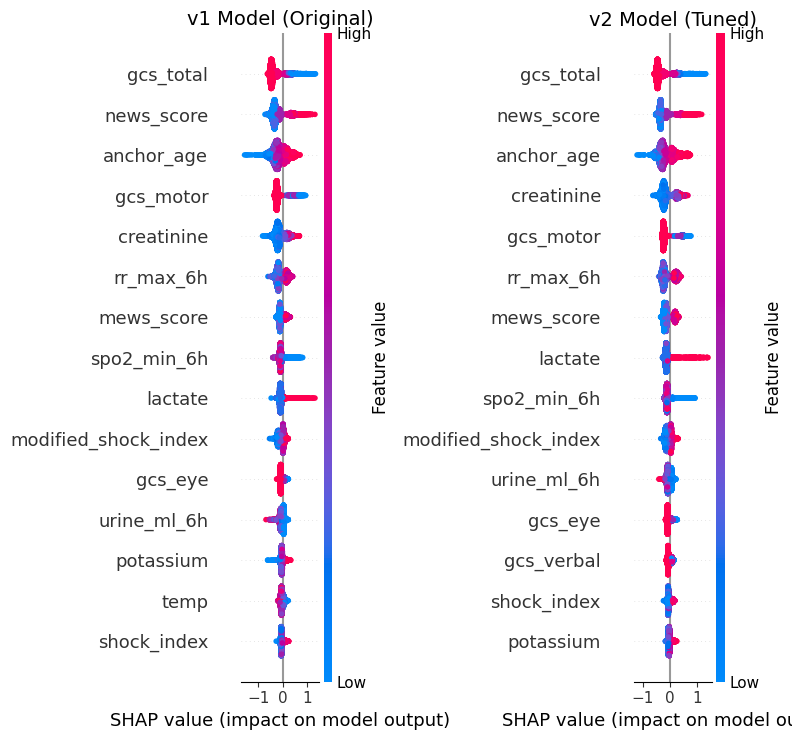

✓ 저장: ../reports/shap_summary_v1_vs_v2_death_next_24h.png


In [17]:
# ==============================================================================
# Step 7: Summary Plot 비교 (v1 vs v2)
# ==============================================================================

print("\nStep 7: Summary Plot 생성")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# --- v1 Summary Plot ---
plt.sca(axes[0])
shap.summary_plot(
    v1_shap_values,
    X_sample,
    feature_names=feature_cols,
    max_display=15,
    show=False
)
axes[0].set_title('v1 Model (Original)', fontsize=14)

# --- v2 Summary Plot ---
plt.sca(axes[1])
shap.summary_plot(
    v2_shap_values,
    X_sample,
    feature_names=feature_cols,
    max_display=15,
    show=False
)
axes[1].set_title('v2 Model (Tuned)', fontsize=14)

plt.tight_layout()

summary_path = os.path.join(OUTPUT_DIR, f'shap_summary_v1_vs_v2_{TARGET}.png')
plt.savefig(summary_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 저장: {summary_path}")


Step 8: Bar Plot 비교


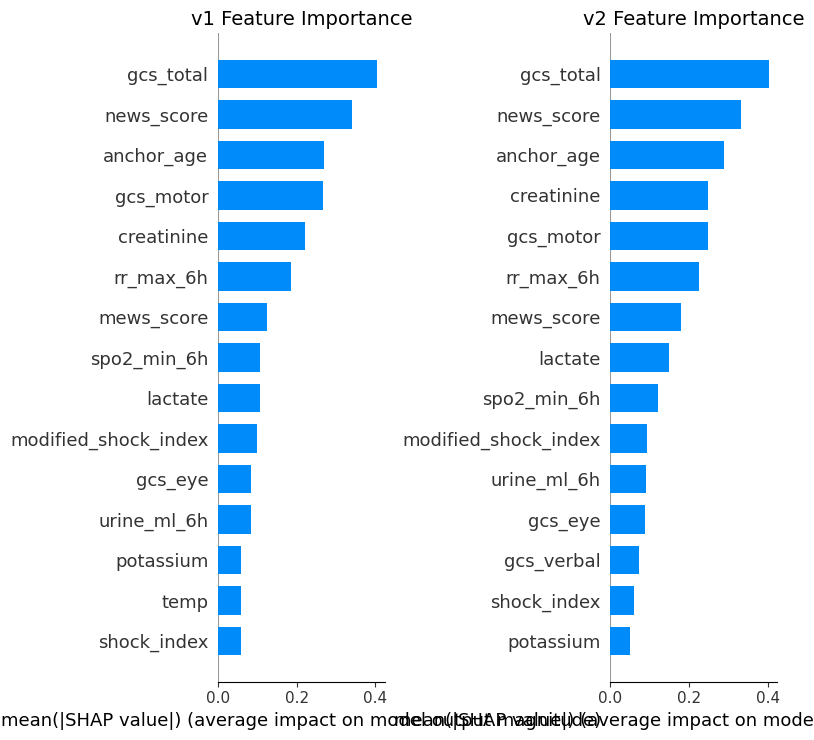

✓ 저장: ../reports/shap_bar_v1_vs_v2_death_next_24h.png


In [18]:
# ==============================================================================
# Step 8: Bar Plot 비교 (v1 vs v2)
# ==============================================================================

print("\nStep 8: Bar Plot 비교")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- v1 Bar Plot ---
plt.sca(axes[0])
shap.summary_plot(
    v1_shap_values,
    X_sample,
    feature_names=feature_cols,
    plot_type='bar',
    max_display=15,
    show=False
)
axes[0].set_title('v1 Feature Importance', fontsize=14)

# --- v2 Bar Plot ---
plt.sca(axes[1])
shap.summary_plot(
    v2_shap_values,
    X_sample,
    feature_names=feature_cols,
    plot_type='bar',
    max_display=15,
    show=False
)
axes[1].set_title('v2 Feature Importance', fontsize=14)

plt.tight_layout()

bar_path = os.path.join(OUTPUT_DIR, f'shap_bar_v1_vs_v2_{TARGET}.png')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 저장: {bar_path}")

In [19]:
# ==============================================================================
# Step 9: 결과 저장
# ==============================================================================

print("\nStep 9: 결과 저장")

# Feature Importance 비교 저장
importance_path = os.path.join(OUTPUT_DIR, f'feature_importance_v1_vs_v2_{TARGET}.csv')
importance_comparison.to_csv(importance_path, index=False)
print(f"✓ {importance_path}")

# 그룹별 비교 저장
group_path = os.path.join(OUTPUT_DIR, f'group_importance_v1_vs_v2_{TARGET}.csv')
df_group_comparison.to_csv(group_path, index=False)
print(f"✓ {group_path}")

print("\n=== 13. SHAP Analysis v2 완료 ===")


Step 9: 결과 저장
✓ ../reports/feature_importance_v1_vs_v2_death_next_24h.csv
✓ ../reports/group_importance_v1_vs_v2_death_next_24h.csv

=== 13. SHAP Analysis v2 완료 ===
